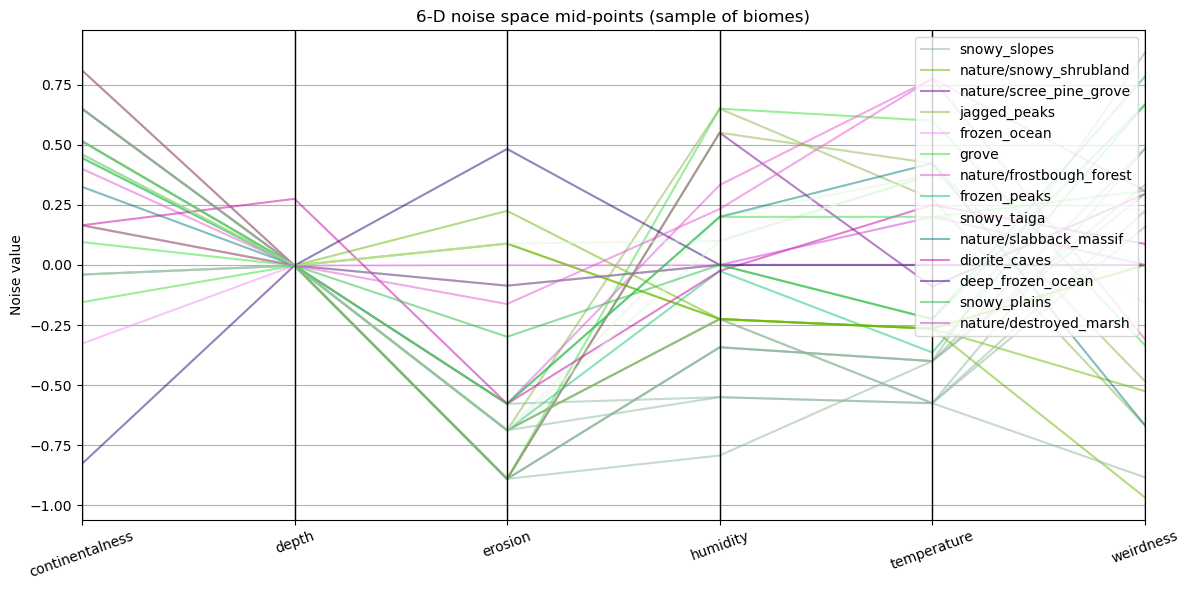

In [3]:
import json, pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
import os, textwrap

# Load the JSON preset (uploaded as normal.json)
json_path = 'normal.json'
with open(json_path, 'r') as f:
    data = json.load(f)

# Extract the biome list
biomes = data['dimensions']['minecraft:overworld']['generator']['biome_source']['biomes']

# Build a DataFrame with interval mid‑points for each 6‑D parameter
records = []
for entry in biomes:
    p = entry['parameters']
    # Skip the scalar offset (Minecraft shifts noise curves) – not part of the main 6D space
    record = {
        'biome': entry['biome'],
        'continentalness': sum(p['continentalness']) / 2,
        'depth':          sum(p['depth'])          / 2,
        'erosion':        sum(p['erosion'])        / 2,
        'humidity':       sum(p['humidity'])       / 2,
        'temperature':    sum(p['temperature'])    / 2,
        'weirdness':      sum(p['weirdness'])      / 2
    }
    records.append(record)

df = pd.DataFrame(records)

# Because there are many unique biome IDs, plotting all makes a messy legend.
# Compress the biome id to the namespace part for readability (after the colon).
df['biome_group'] = df['biome'].apply(lambda s: s.split(':')[-1])

# Sample at most N biomes to keep the plot legible
N = 30
sample_df = df.sample(N, random_state=0) if len(df) > N else df

plt.figure(figsize=(12, 6))
parallel_coordinates(sample_df[['biome_group', 'continentalness', 'depth',
                                'erosion', 'humidity', 'temperature', 'weirdness']],
                     'biome_group', alpha=0.5)
plt.title("6‑D noise space mid‑points (sample of biomes)")
plt.ylabel("Noise value")
plt.xticks(rotation=20)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('biome_noise_space.png', dpi=300)
plt.show()

In [ ]:
import json, pandas as pd

json_path = 'normal.json'
with open(json_path) as f:
    data = json.load(f)

params = ['continentalness','depth','erosion','humidity','temperature','weirdness']
biomes_raw = data['dimensions']['minecraft:overworld']['generator']['biome_source']['biomes']

def merge_intervals(intervals):
    iv = sorted(intervals, key=lambda x: x[0])
    merged = []
    for lo, hi in iv:
        if not merged or lo > merged[-1][1]:
            merged.append([lo, hi])
        else:
            merged[-1][1] = max(merged[-1][1], hi)
    return merged

def biome_union(biome_id):
    relevant = [b for b in biomes_raw if b['biome'] == biome_id]
    if not relevant:
        return None
    rows = []
    for par in params:
        intervals = [b['parameters'][par] for b in relevant]
        merged = merge_intervals(intervals)
        # represent as short string
        merged_str = "; ".join([f"[{lo:.3g}, {hi:.3g}]" for lo, hi in merged])
        rows.append({'parameter': par, 'combined interval(s)': merged_str})
    return pd.DataFrame(rows)

exemplars = {
    "minecraft:dripstone_caves": biome_union("minecraft:dripstone_caves"),
    "the_winter_rescue:diorite_caves": biome_union("the_winter_rescue:diorite_caves"),
    "minecraft:deep_frozen_ocean": biome_union("minecraft:deep_frozen_ocean")
}

for name, df in exemplars.items():
    if df is not None:
        display_dataframe_to_user(name, df)
